## Imports

In [1]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

## Define experimental parameters

In [21]:
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = 0.1 * gm      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times = None,  # Use default measurement times
    initial_time=-8.0/inverse_pulse_width,
    final_time=8.0/inverse_pulse_width,
    time_interval=4.0/inverse_pulse_width,
    initial_time_uncertainty=0.0/inverse_pulse_width
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.0001,  
    dephasing = 0.0001,      
    relaxation = 0.0001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavity levels:             2
  Qubit levels:              2
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                    0.0942
  Photon cavity coupling: 0.1885
  Inverse pulse width:    0.0188
MEASUREMENT PROTOCOL
  Mode:                 Interval-based
  Initial time:         -424.4132
  Final time:           424.4132
  Time interval:        212.2066
  Number of measurements:      5
  Computed times:       [-424.4131815783876, -212.2065907891938, 0.0, 212.2065907891938, 424.4131815783876]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:      0.0001
  Dephasing rate:         0.0001
  Relaxation rate:        0.0001
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\simon\AppData\Local\Temp\ipykernel_9316\2951429617.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


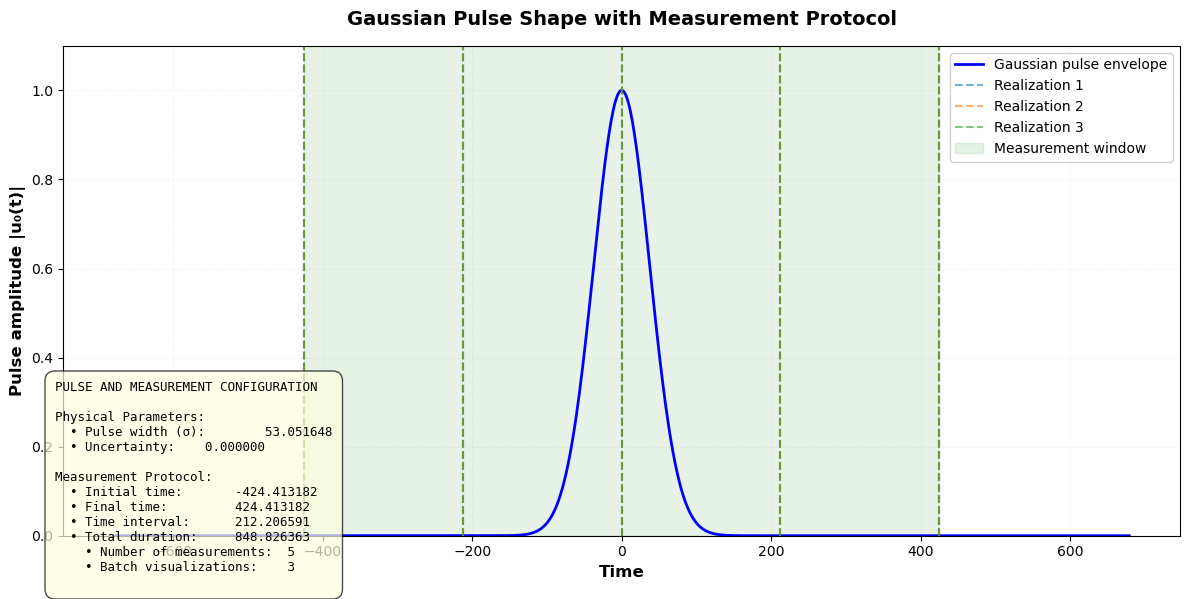

In [22]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=3
)
fig.show()

## Define trainable parameters

In [39]:
parameters = TrainableParameters()
parameters.add_rotation_angles(['ry1', 'ry2'], [np.pi/2, -np.pi/2], optimizer=optax.sgd(0.1))
# Add measurement interval as a trainable parameter will overwrite the fixed experimental setting
parameters.add_measurement_interval(
    initial_value=3.0/inverse_pulse_width,
    name=['interval'],
    grid_min=0.5/inverse_pulse_width, 
    grid_max=4.0/inverse_pulse_width,
    grid_resolution=20,
)

print(parameters)

Trainable Parameters: 3
  Rotation Angles:
    ry1: 1.5708 rad (90.00°)
    ry2: -1.5708 rad (-90.00°)
  Measurement Times:
    interval: 159.1549


## Define experiment

In [40]:
experiment = SingleQubitExperiment(exp_parameters, parameters)
# Print the measurement interval to verify it's set correctly
print(experiment.get_measurement_interval())

159.15494309189535


## Test Single Simulation

In [41]:
results = experiment.run_simulation()
print(results)

MODE: Single Simulation
  Current Parameters:
     ry1: 1.570796 rad (90.00°)
     ry2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.967458
     P(without photon): 0.139462
     Contrast:          0.827996


## Run Optimization

In [42]:

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize_rotations(
    theta_init=[1.5, -1.5],
    num_steps=200,
    verbose=True,
    batch_size=1,
    tolerance=1e-7
)

Configuration:
    Max iterations: 200
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: ry1=1.500 rad, ry2=-1.500 rad
    Measurement interval parameters:
        interval=159.154943
Step  ry1         ry2         Contrast    Grad Norm
----------------------------------------------------------------------
0     1.500000    -1.500000   0.825958    6.25e-02    
10    1.533249    -1.526740   0.827825    2.63e-02    
20    1.546527    -1.539977   0.828181    1.16e-02    
30    1.552385    -1.545833   0.828250    5.14e-03    
40    1.554975    -1.548422   0.828264    2.27e-03    
50    1.556119    -1.549566   0.828266    1.00e-03    
60    1.556625    -1.550071   0.828267    4.44e-04    
70    1.556848    -1.550295   0.828267    1.96e-04    
80    1.556947    -1.550394   0.828267    8.68e-05    
90    1.556991    -1.550437   0.828267    3.84e-05    
100   1.557010    -1.550457   0.828267    1.70e-05    
110   1.557018    -1.550465   0.828267    7.49e-06 

In [43]:
print(history)

MODE: Optimization
     Total iterations: 164
     Best epoch:        164
     Converged: True
     Final gradient norm: 9.899939e-08
  Best Parameters:
     ry1: 1.557025 rad (89.21°)
     ry2: -1.550472 rad (-88.84°)
  Detection Probabilities:
     P(with photon):    0.967056
     P(without photon): 0.138789
     Contrast:          0.828267


## Visualization Dashboard

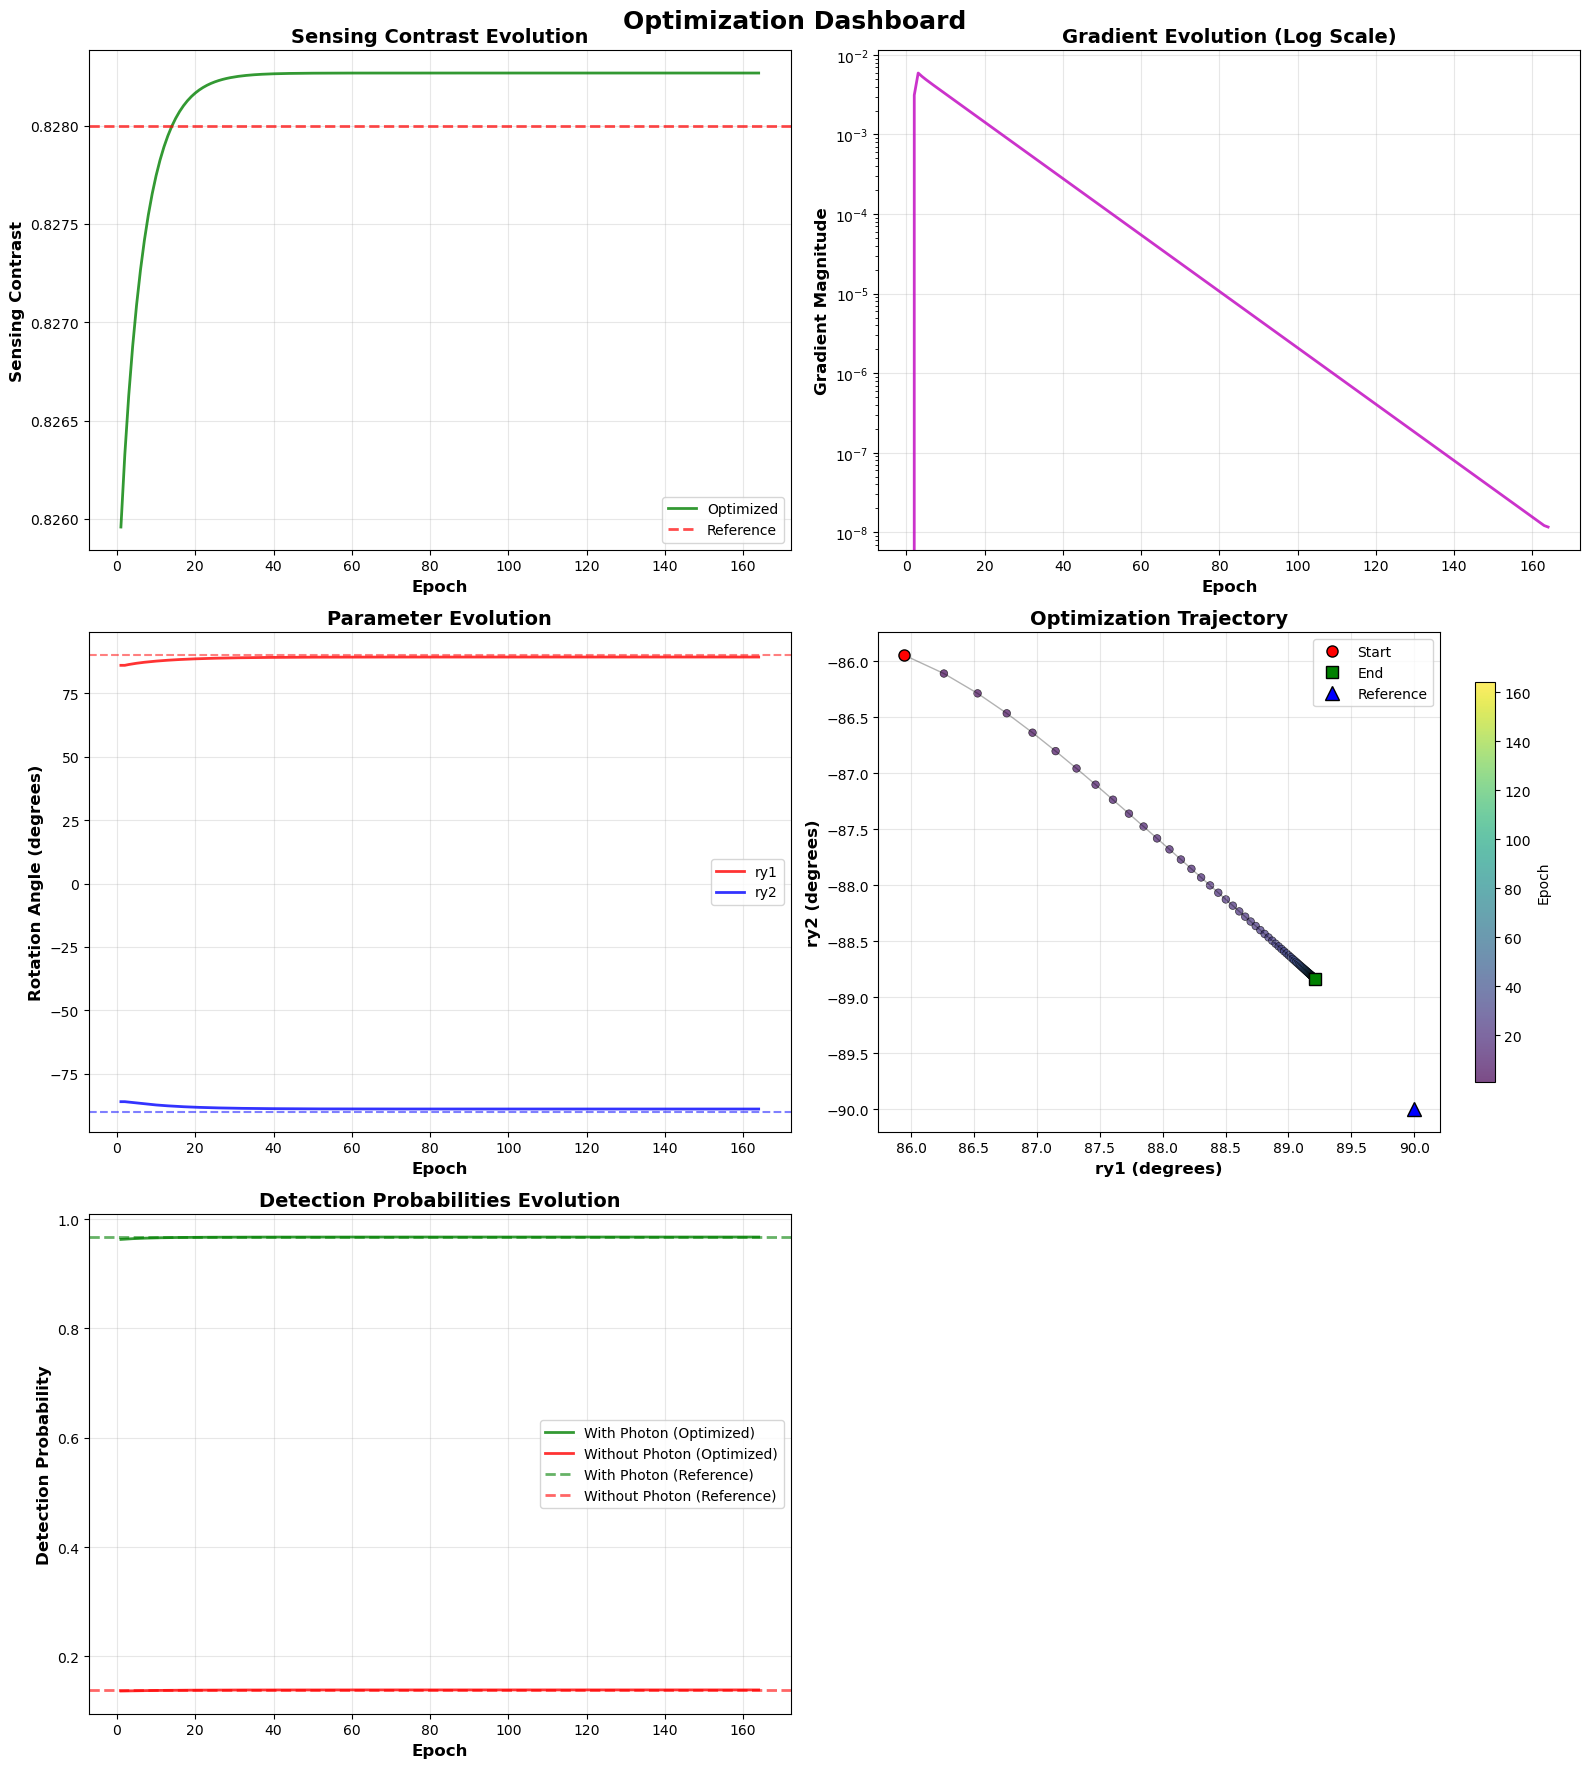

In [44]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [45]:
time_callback = experiment.optimize_measurement_times(batch_size=10, mode='discrete', verbose=True)

Computing time interval landscape (mode: discrete)...
  Rotation angles: θ₁=89.2°, θ₂=271.2°
  Resolution: 20 points
  Batch size: 10 realizations
  Total evolution time: 848.8264
  Requested interval bounds: [26.525823848649225, 212.2065907891938]
  Progress: 100.0% (interval=212.2066, n_meas=5, contrast=0.805676)
Completed in 33.0s (1.652s per point)
  Optimal interval: 121.2609 (n_meas=8, contrast=0.825467)


Time interval landscape plot saved to: results/time_interval_opt.pdf


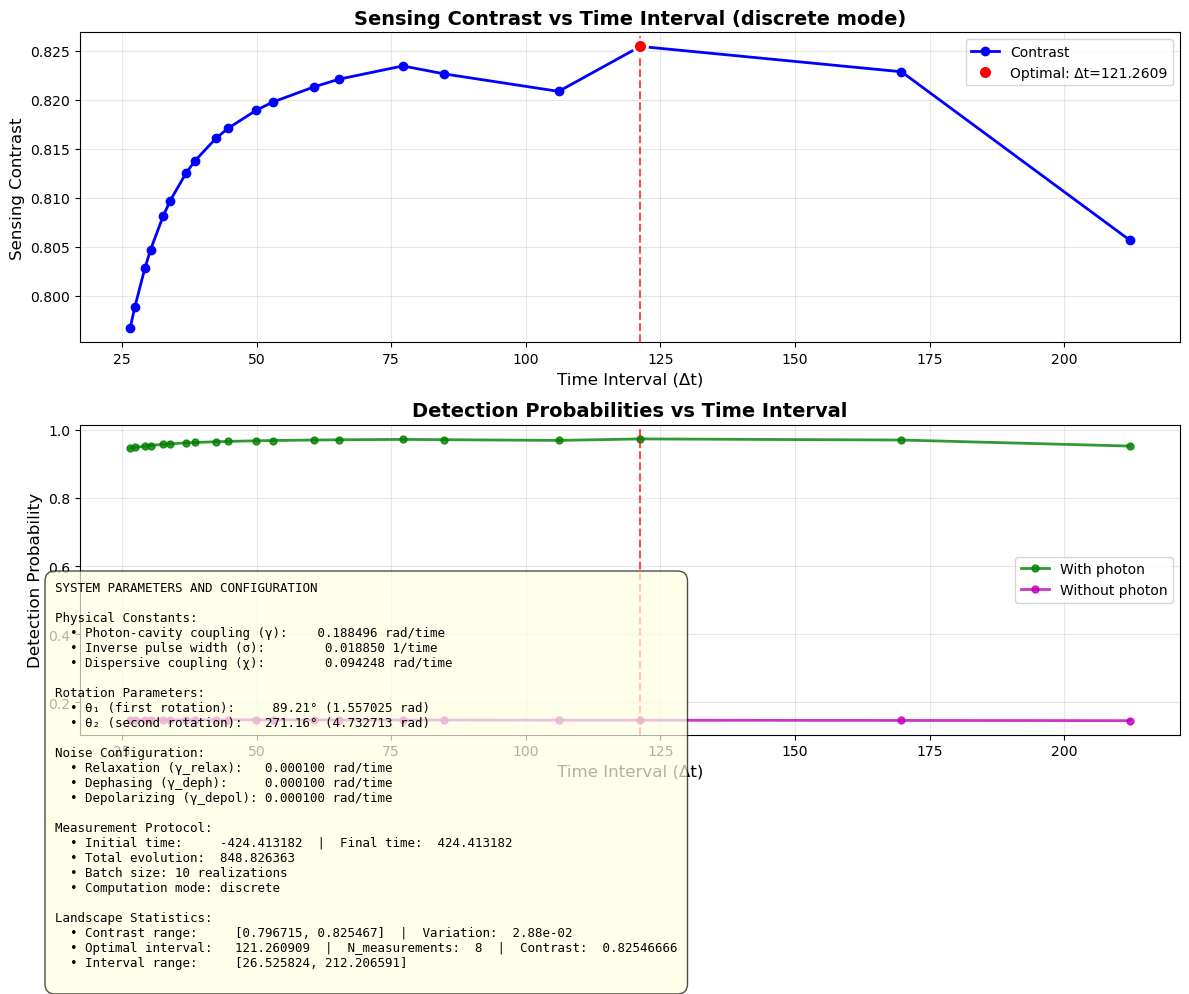

In [46]:
from qsopt.utils.visualization import plot_time_interval_landscape

fig = plot_time_interval_landscape(
    landscape_data=time_callback,
    exp_params=experiment.experimental_params,
    save_path='results/time_interval_opt.pdf'
)


In [47]:
# When using more measurements reduce the rotation optimizer learning rate
experiment.trainable_params.rotation_optimizer = optax.sgd(0.05)
history = experiment.optimize_rotations(
    theta_init=[1.558, 4.734],
    num_steps=30,
    verbose=True,
    batch_size=10,
    tolerance=1e-7,
    verbose_step=10
)

Configuration:
    Max iterations: 30
    Batch size: 10
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: ry1=1.558 rad, ry2=4.734 rad
    Measurement interval parameters:
        interval=121.260909
Step  ry1         ry2         Contrast    Grad Norm
----------------------------------------------------------------------
0     1.558000    4.734000    0.825452    1.44e-02    
1     1.556818    4.733186    0.825467    6.52e-03    
2     1.556220    4.732927    0.825470    3.42e-03    
3     1.555880    4.732900    0.825471    2.33e-03    
4     1.555656    4.732965    0.825471    1.94e-03    
5     1.555489    4.733064    0.825472    1.75e-03    
6     1.555352    4.733173    0.825472    1.61e-03    
7     1.555232    4.733280    0.825472    1.48e-03    
8     1.555125    4.733382    0.825473    1.36e-03    
9     1.555027    4.733477    0.825473    1.26e-03    
10    1.554938    4.733565    0.825473    1.16e-03    
11    1.554856    4.733647    0.825473    1.07e-03  